C:\Users\diego\AppData\Local\Temp\ipykernel_3120\2151354517.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


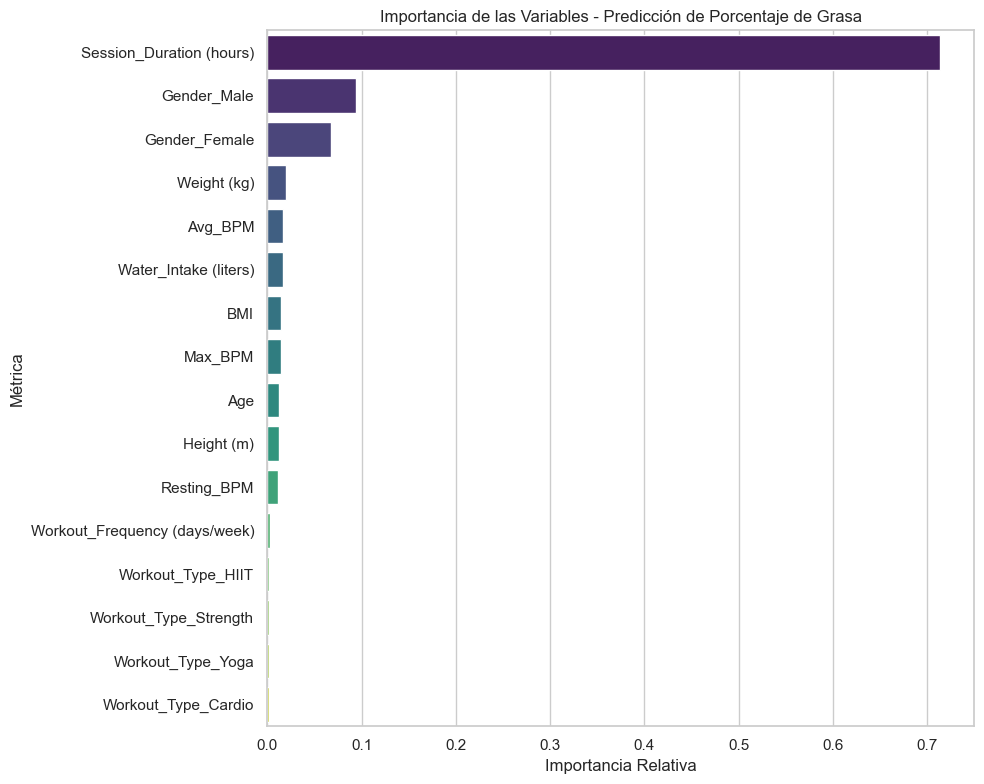

In [1]:
import sys
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

sys.path.append('..')
from src.data_preprocessing import load_gym_data

sns.set_theme(style="whitegrid")
PLOTS_DIR = '../results/plots/'

# Cargar el modelo optimizado que acabamos de guardar
model_path = '../models/trained_models/optimized_rf_regressor.pkl'
best_pipeline = joblib.load(model_path)

# Cargar datos
df = load_gym_data('../data/gym_members_exercise_tracking.csv')
X = df.drop(columns=['Fat_Percentage'])

# Extraer el preprocesador y el modelo del pipeline
preprocessor = best_pipeline.named_steps['preprocessor']
rf_model = best_pipeline.named_steps['regressor']

# Obtener los nombres de las columnas transformadas (esto es crucial tras hacer OneHotEncoding)
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(['Gender', 'Workout_Type'])
num_features = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
                'Resting_BPM', 'Session_Duration (hours)', 'Water_Intake (liters)', 
                'Workout_Frequency (days/week)', 'BMI']

all_feature_names = list(num_features) + list(cat_features)

# Extraer las importancias
importances = rf_model.feature_importances_

# Crear DataFrame para visualizar
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Importancia de las Variables - Predicción de Porcentaje de Grasa')
plt.xlabel('Importancia Relativa')
plt.ylabel('Métrica')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '04_feature_importance.png'))
plt.show()